In [29]:
%run "/home/nichettg/Codici/Laboratorio/moduli.py"

In [30]:
def nome (stringa):
    """
    Estrae il nome, cioè la frequenza, dal titolo di ogni file input letto
    """
    
    stringa_nuova = stringa.replace('./Data/tors_','').replace('.csv','').replace('h','H')
    return stringa_nuova

# 1. Raccolta Dati

In [31]:
input_files = [f"./Data/{nome_file}" for nome_file in sorted(os.listdir('./Data'))]
dati= {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    dati[nome(input_file)] = {
        "tempo": letti["Tempo"],
        "forzante": letti["Forzante"],
        "pendolo" : letti["Pendolo"],
        "ampiezza" : letti["Ampiezza"],
        "fase" : letti["Fase"],
    }

In [32]:
gf.display_dizionario(dati)

# 2. Analisi

## 2.1 Confronto Frequenze Forzanti

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


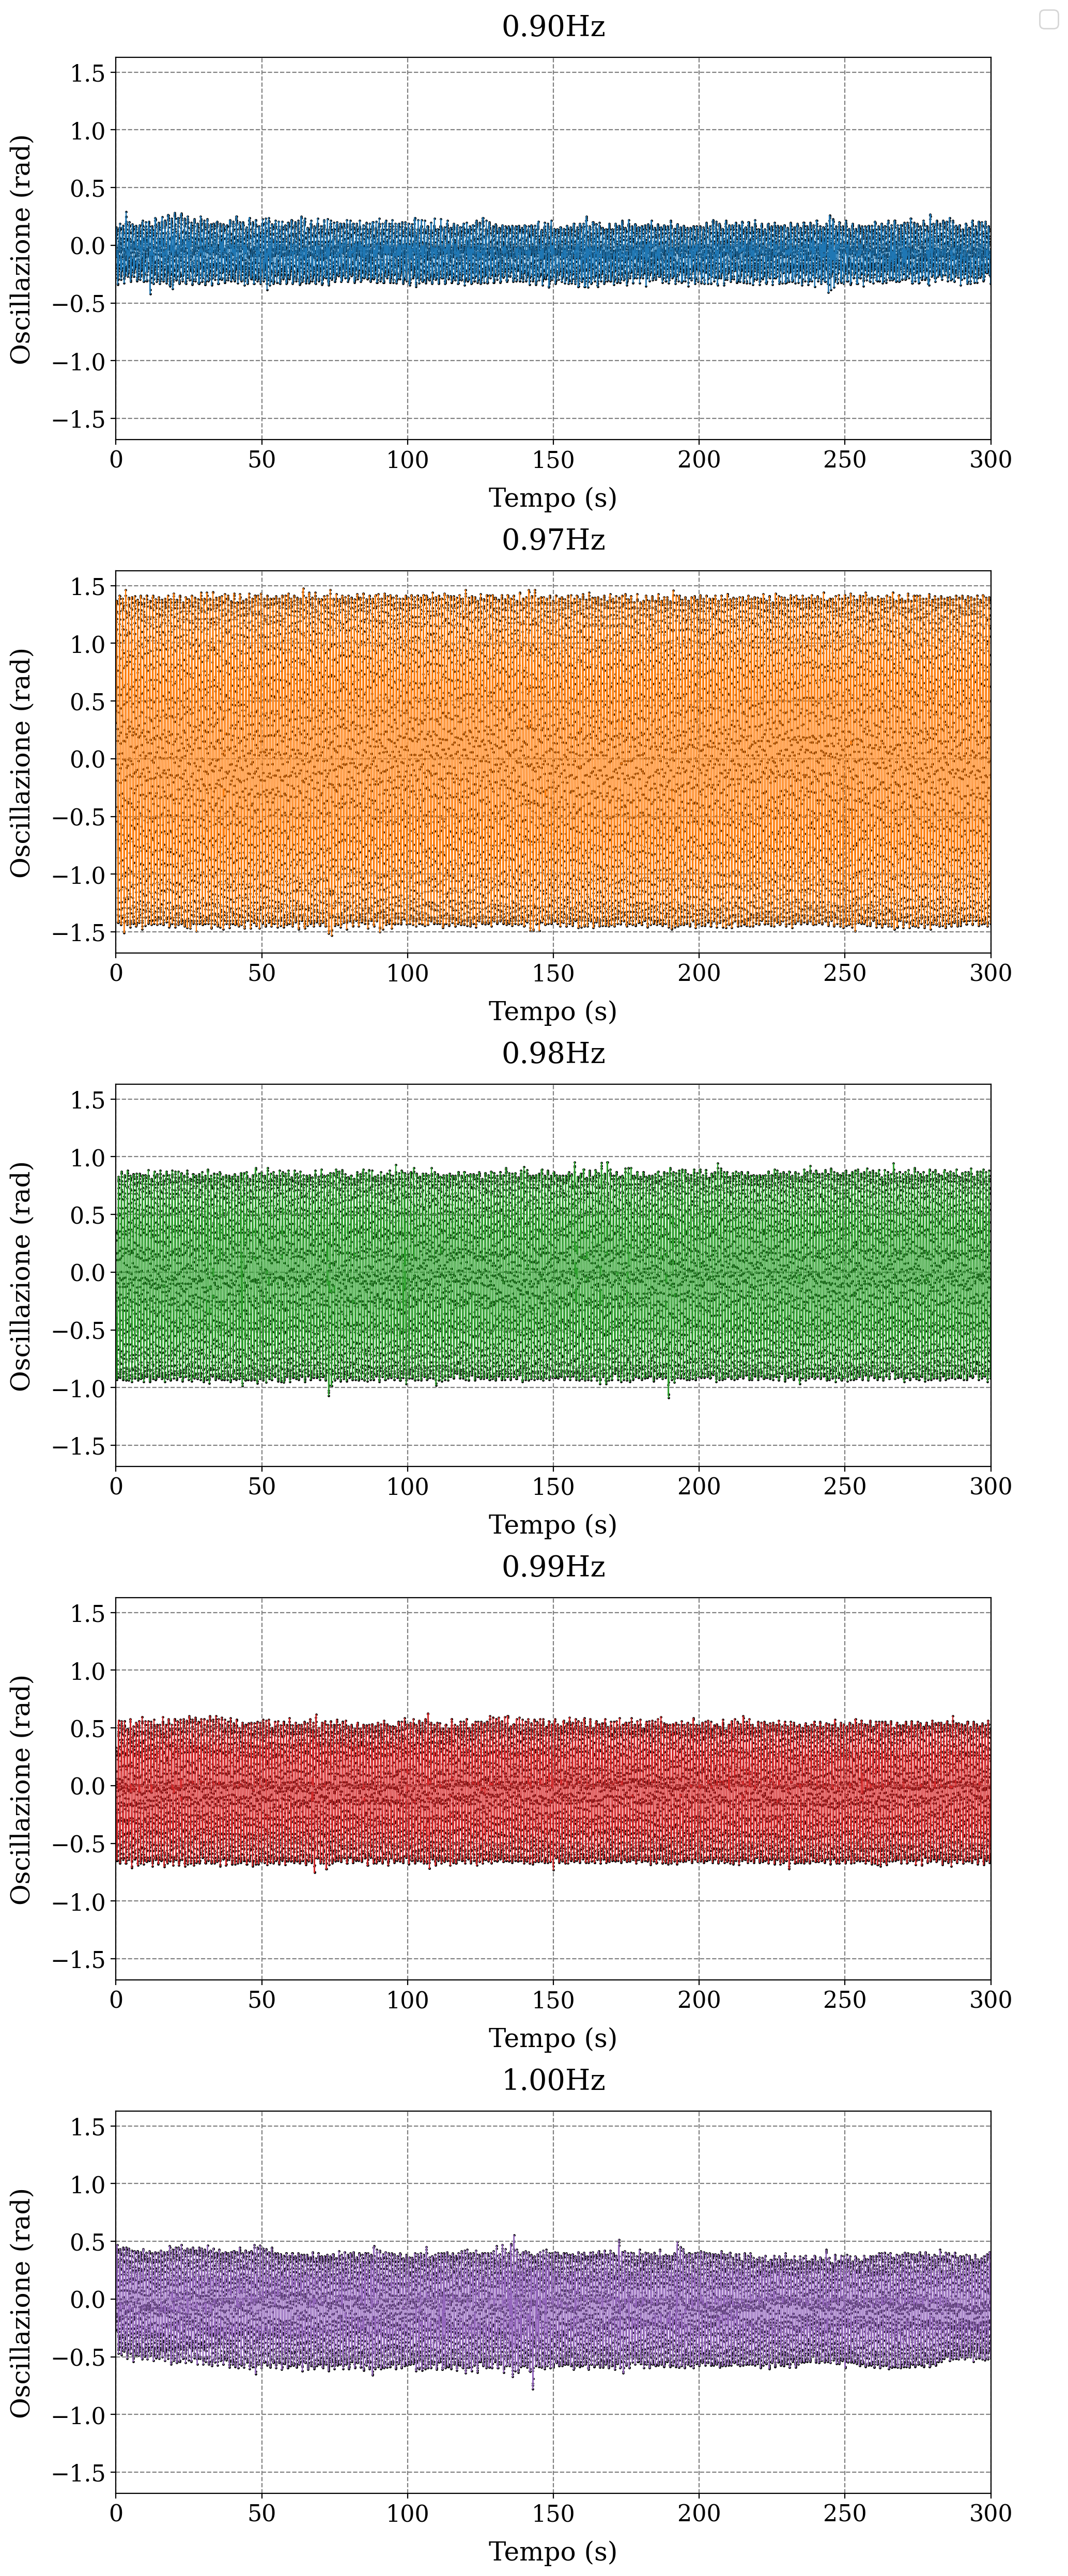

In [46]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, input_file in enumerate(input_files):

    ax = axes[i]

    titolo = nome(input_file)
    colore = next(color_cycle)

    x = dati[titolo]["tempo"]
    y = dati[titolo]["pendolo"] * (2*np.pi)

    """
    y1 = dati[titolo]["ampiezza"] / (2*np.pi) # ampiezza (soluzione) in rad
    y2 = dati[titolo]["forzante"] / (2*np.pi) / 1000 # ampiezza forzante in rad

    ax.plot(x, y1, color=colore, linewidth=0.7)
    ax.scatter(x, y1, color="black", s=0.7)

    ax.plot(x, y2, color=gf.darken(colore), linewidth=0.7)
    ax.scatter(x, y2, color="black", s=0.7)
    """

    ax.plot(x, y, color=colore, linewidth=0.7)
    ax.scatter(x, y, color="black", s=0.5)

    gf.parametri_grafico(ax, titolo, "Tempo (s)", "Oscillazione (rad)")
    ax.set_xlim(0,300)
gf.salva_grafico(fig, "./Images/ConfrontoForzanti.pdf")

## 2.2 Calcolo Ampiezze Medie

Raggio dell'intorno rispetto al quale i valori salvati sono i massimi. Di tali valori verrà poi calcolata la media, considerata come ampiezza media.

In [34]:
raggio = 20
grafico_controllo = True

Serie 0.90Hz: 208 massimi 
 Media: 0.192 
 Deviazione standard: 0.029 

Serie 0.97Hz: 256 massimi 
 Media: 1.403 
 Deviazione standard: 0.021 

Serie 0.98Hz: 242 massimi 
 Media: 0.862 
 Deviazione standard: 0.026 

Serie 0.99Hz: 240 massimi 
 Media: 0.550 
 Deviazione standard: 0.025 

Serie 1.00Hz: 249 massimi 
 Media: 0.398 
 Deviazione standard: 0.032 



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


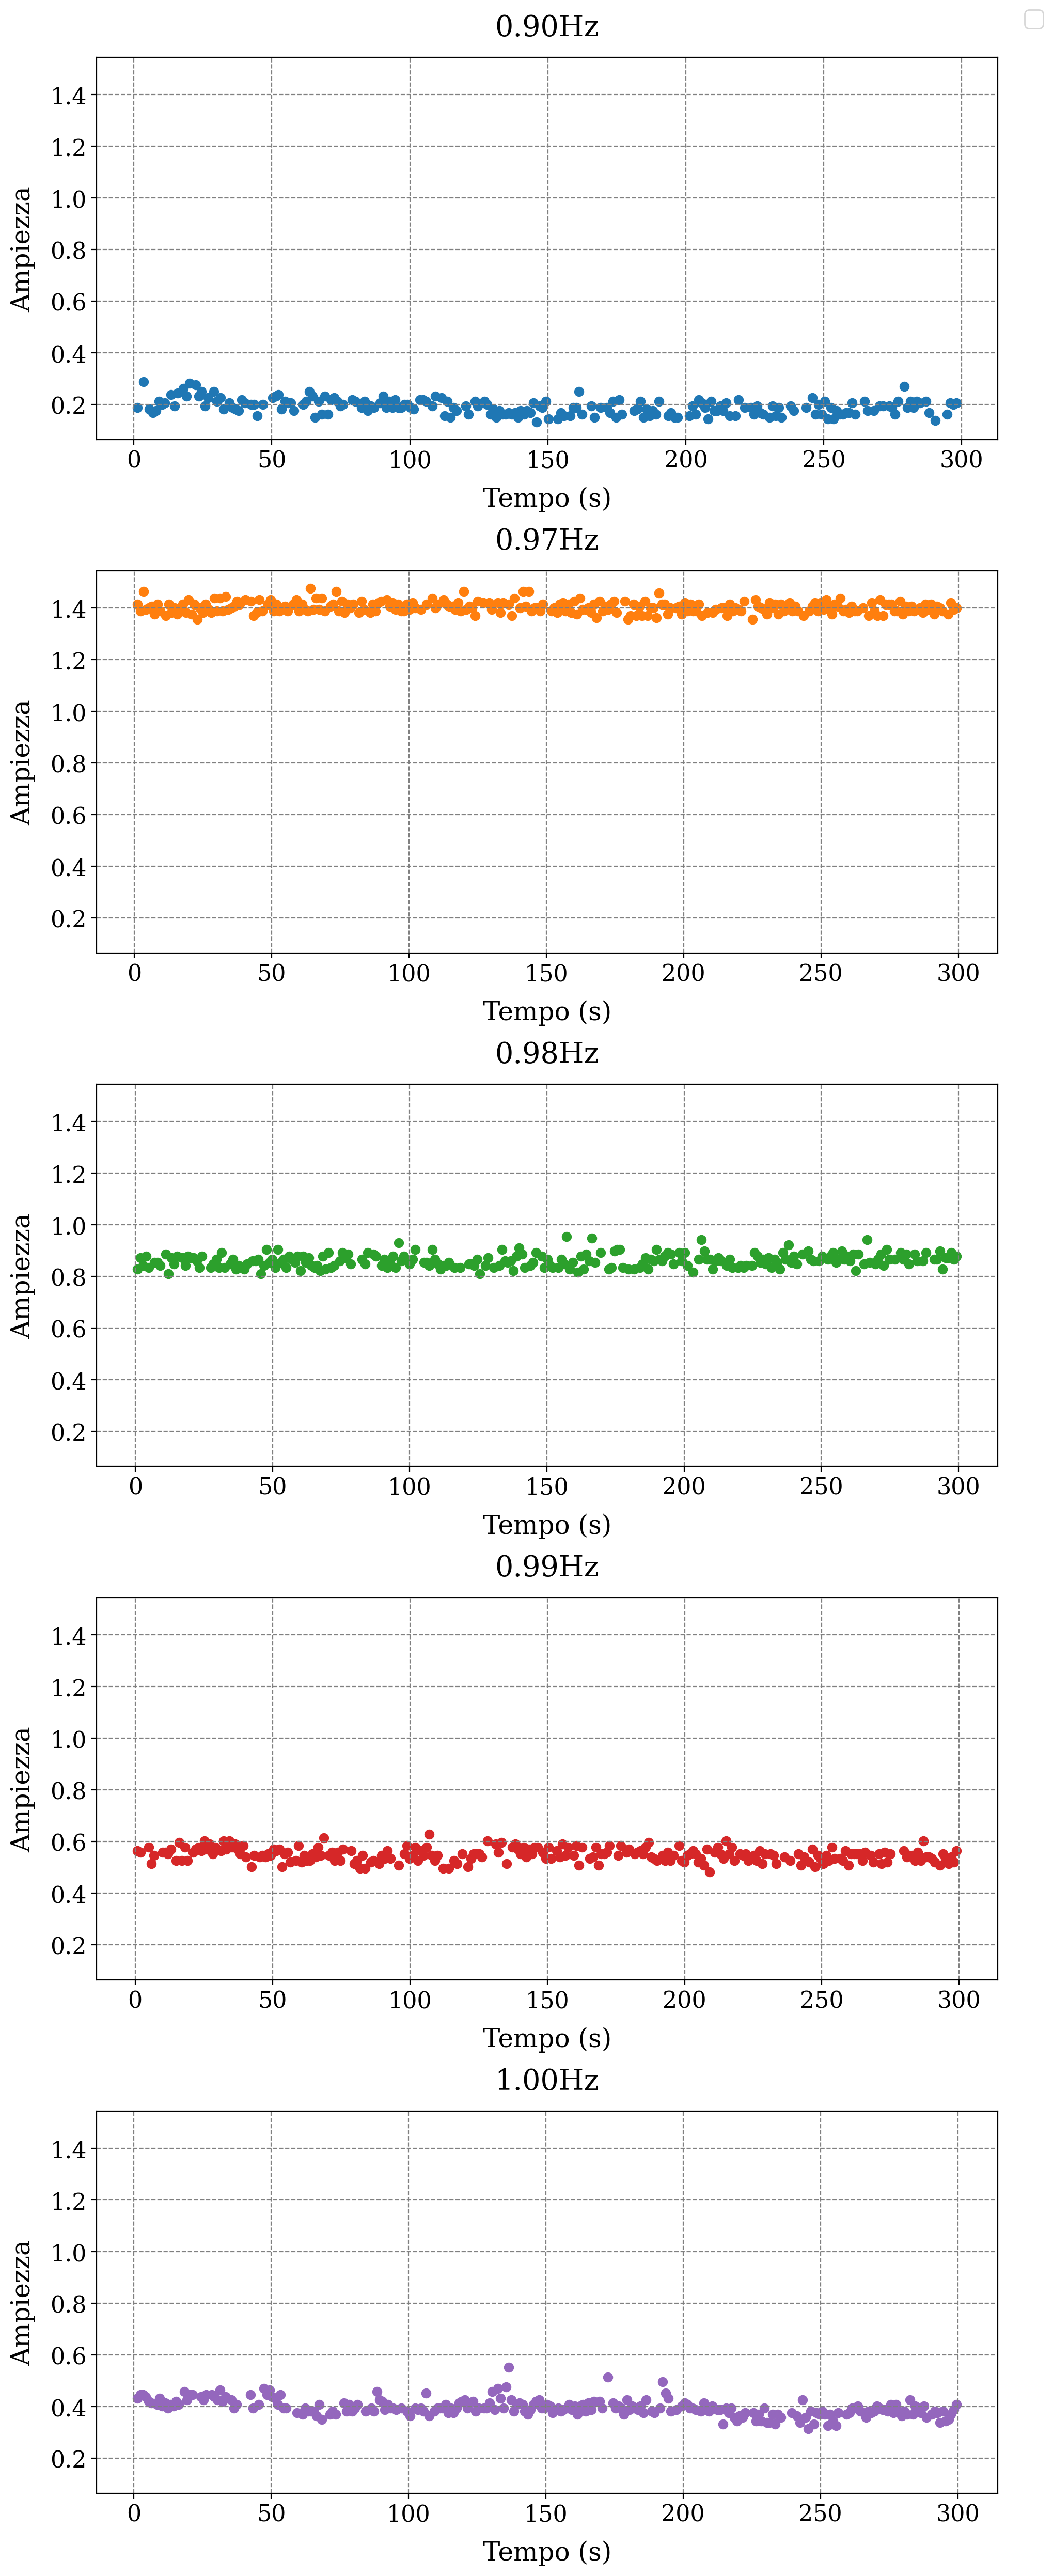

In [ ]:
ampiezze = {}

if grafico_controllo: fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, serie in enumerate(dati):
    valori = dati[serie]["pendolo"] * (2*np.pi)
    tempi = dati[serie]["tempo"]
    massimi, massimi_t = [], []

    for j, val in enumerate(valori):
        if tempi[j] > 300:
            break
        if j < raggio or j > len(valori) - raggio - 1:
            continue
        if all(val > valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            massimi.append(abs(val))
            massimi_t.append(tempi[j])

    ampiezze[serie] = np.mean(massimi)

    print(f"Serie {serie}: {len(massimi)} massimi \n Media: {np.mean(massimi):.3f} \n Deviazione standard: {np.std(massimi):.3f} \n")
    
    if grafico_controllo:
        ax = axes[i]
        colore = next(color_cycle_fisso)
        ax.scatter(massimi_t, massimi, color=colore)
        gf.parametri_grafico(ax, f"{serie}", "Tempo (s)", "Ampiezza")
if grafico_controllo: gf.salva_grafico(fig, f"./Images/ConfrontoMassimi.pdf")

In [48]:
gf.display_dizionario(ampiezze)


0.90Hz,0.19187881284233047
0.97Hz,1.4028192945982672
0.98Hz,0.8624061287738725
0.99Hz,0.5496216347455343
1.00Hz,0.39755656431572045


## 2.3 Fit Lorentziano

---

$$
L(x) = \frac{A}{(B + x^2)^2 + C x^2}
$$

dove:

- ( $A$ ): costante di scala, legata all'altezza del picco  
- ( $B = \omega_0^2$ ): frequenza di risonanza, corrisponde alla posizione del picco  
- ( $C = \gamma^2$ ): larghezza a metà altezza (HWHM), legata allo smorzamento del sistema

$$
L(x) = \frac{A}{(\omega_0^2 + x^2)^2 + \gamma^2 x^2}
$$

---

Seleziona se eseguire o no il fit lorentziano.

In [37]:
fit_lorentziano = True

Fit lorentziano:

A: $(28.5 \pm 3.0) \times 10^{-4}$

B: $(-921.4 \pm 4.0) \times 10^{-3}$

C: $(17.7 \pm 1.7) \times 10^{-4}$

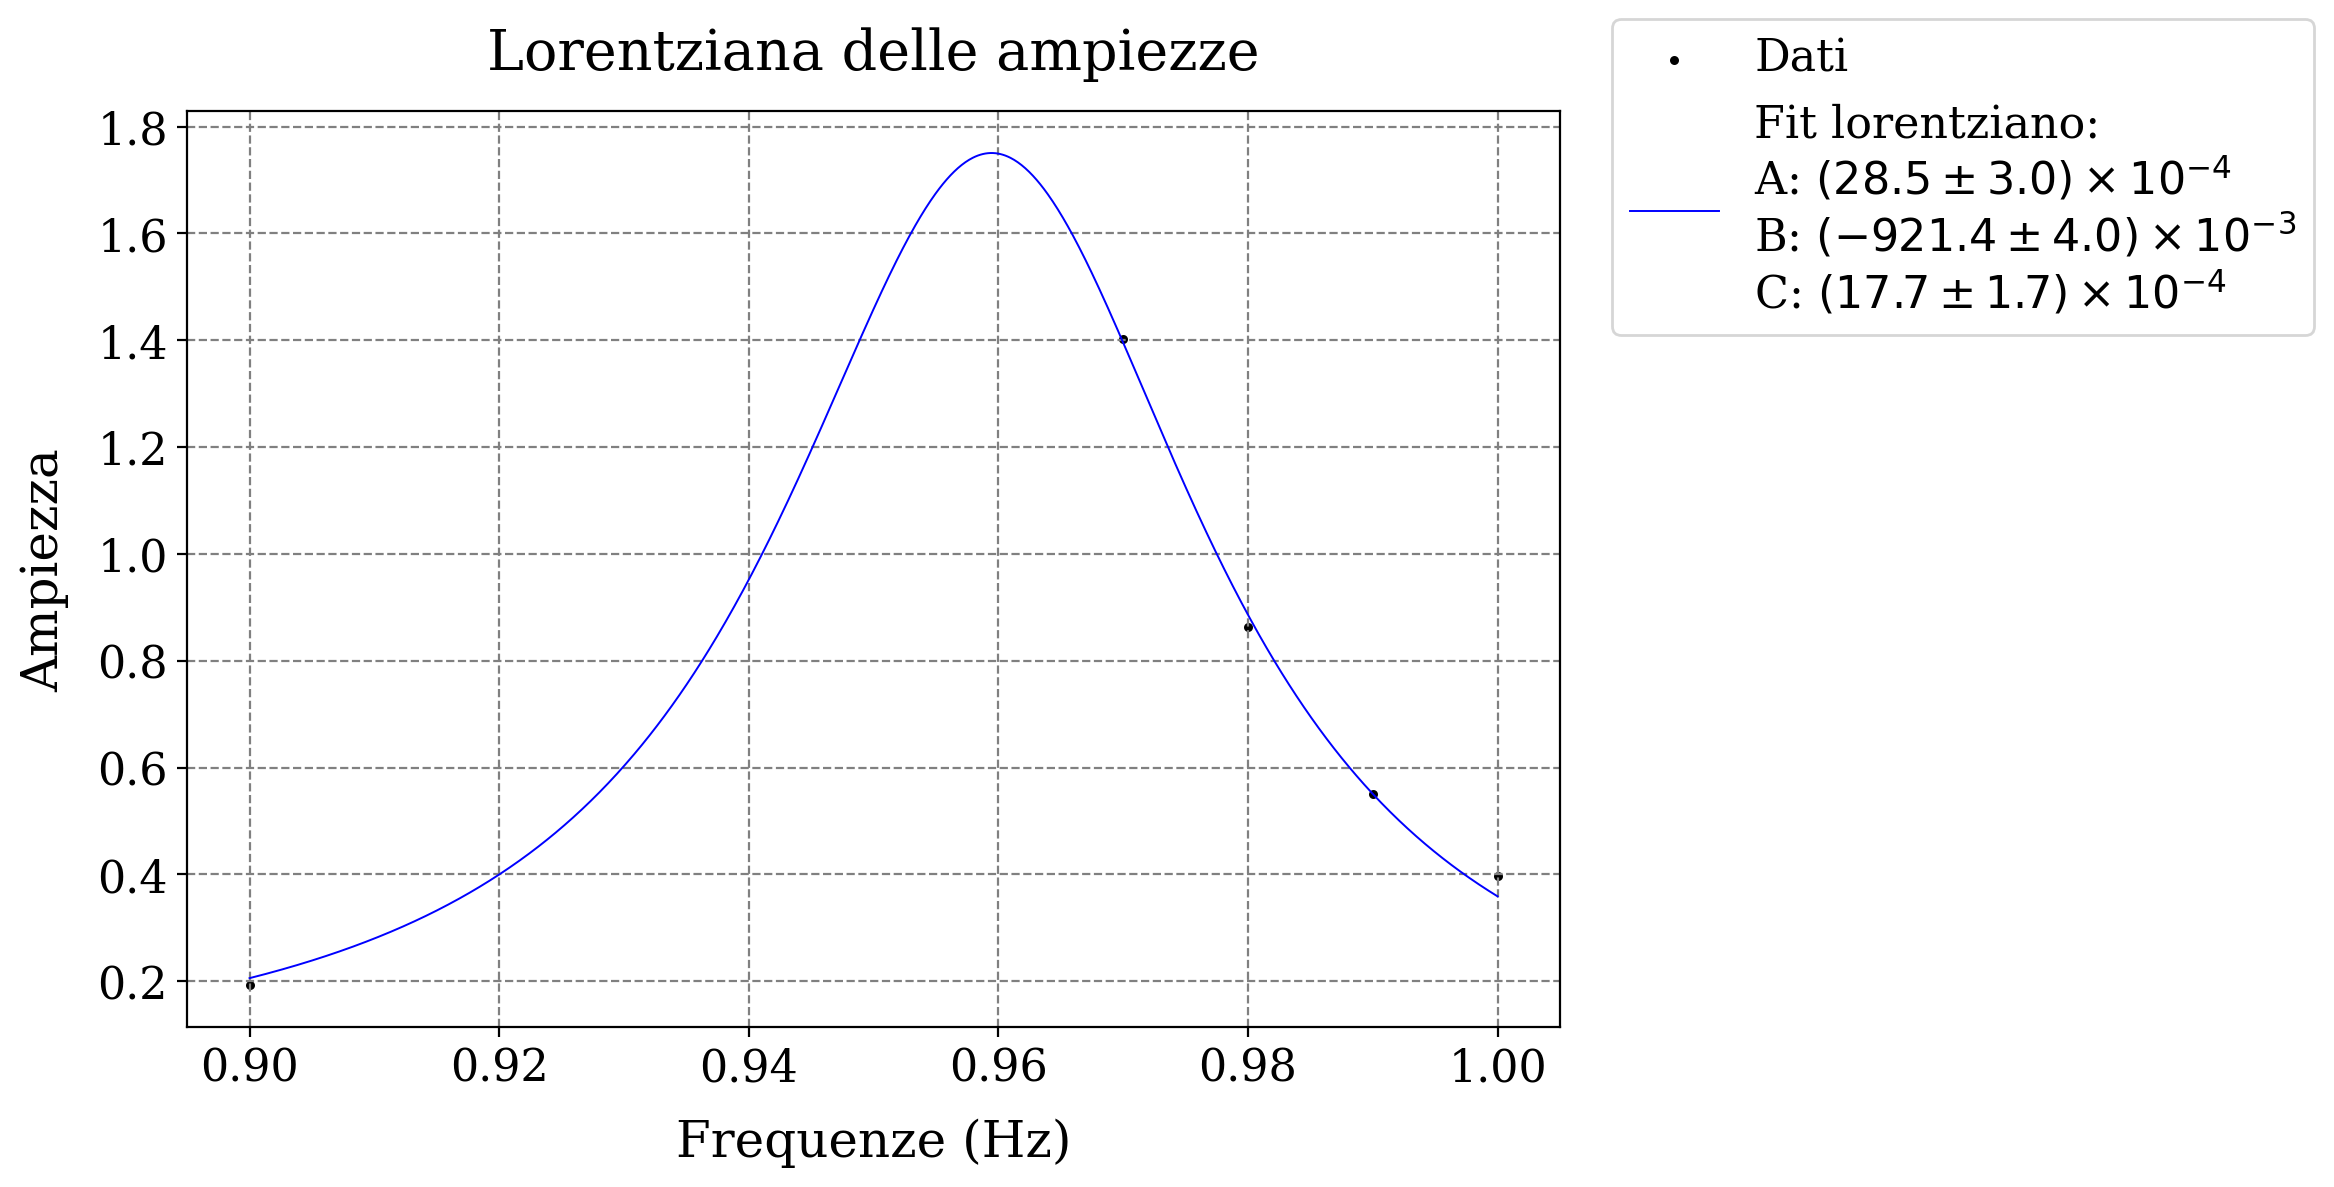

In [ ]:
from scipy.optimize import curve_fit
from IPython.display import display, Markdown

def lorentziana(x, A, B, C):
    return A / ((x**2 + B)**2 + C * x**2)

frequenze = [float(key.replace('Hz', '')) for key in dati.keys()]
ampiezze_valori = list(ampiezze.values())

fig, ax = plt.subplots()
ax.scatter(frequenze, ampiezze_valori, color='black', label='Dati', s=5)

if fit_lorentziano:

    A0 = max(ampiezze_valori)
    B0 = np.mean(frequenze)**2
    C0 = 10

    p0 = [A0, B0, C0]
    popt, pcov = curve_fit(
        lorentziana,
        frequenze,
        ampiezze_valori,
        sigma=errori_y,
        absolute_sigma=True,  # importante se vuoi che pcov abbia senso fisico
        p0=p0
    )
    perr = np.sqrt(np.diag(pcov))

    label = [
        "Fit lorentziano:",
        rf"A: {gf.formatta_errore(popt[0], perr[0])}",
        rf"B: {gf.formatta_errore(popt[1], perr[1])}",
        rf"C: {gf.formatta_errore(popt[2], perr[2])}",
    ]

    x_fit = np.linspace(min(frequenze), max(frequenze), 1000)
    y_fit = lorentziana(x_fit, *popt)
    ax.plot(x_fit, y_fit, color='blue', linewidth=0.7, label='\n'.join(label))

    display(Markdown('\n\n'.join(label)))

gf.parametri_grafico(ax, "Lorentziana delle ampiezze", "Frequenze (Hz)", "Ampiezza")
gf.salva_grafico(fig, "./Images/Lorentziana.pdf")

## 2.4 Confronto Frequenze Smorzate

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


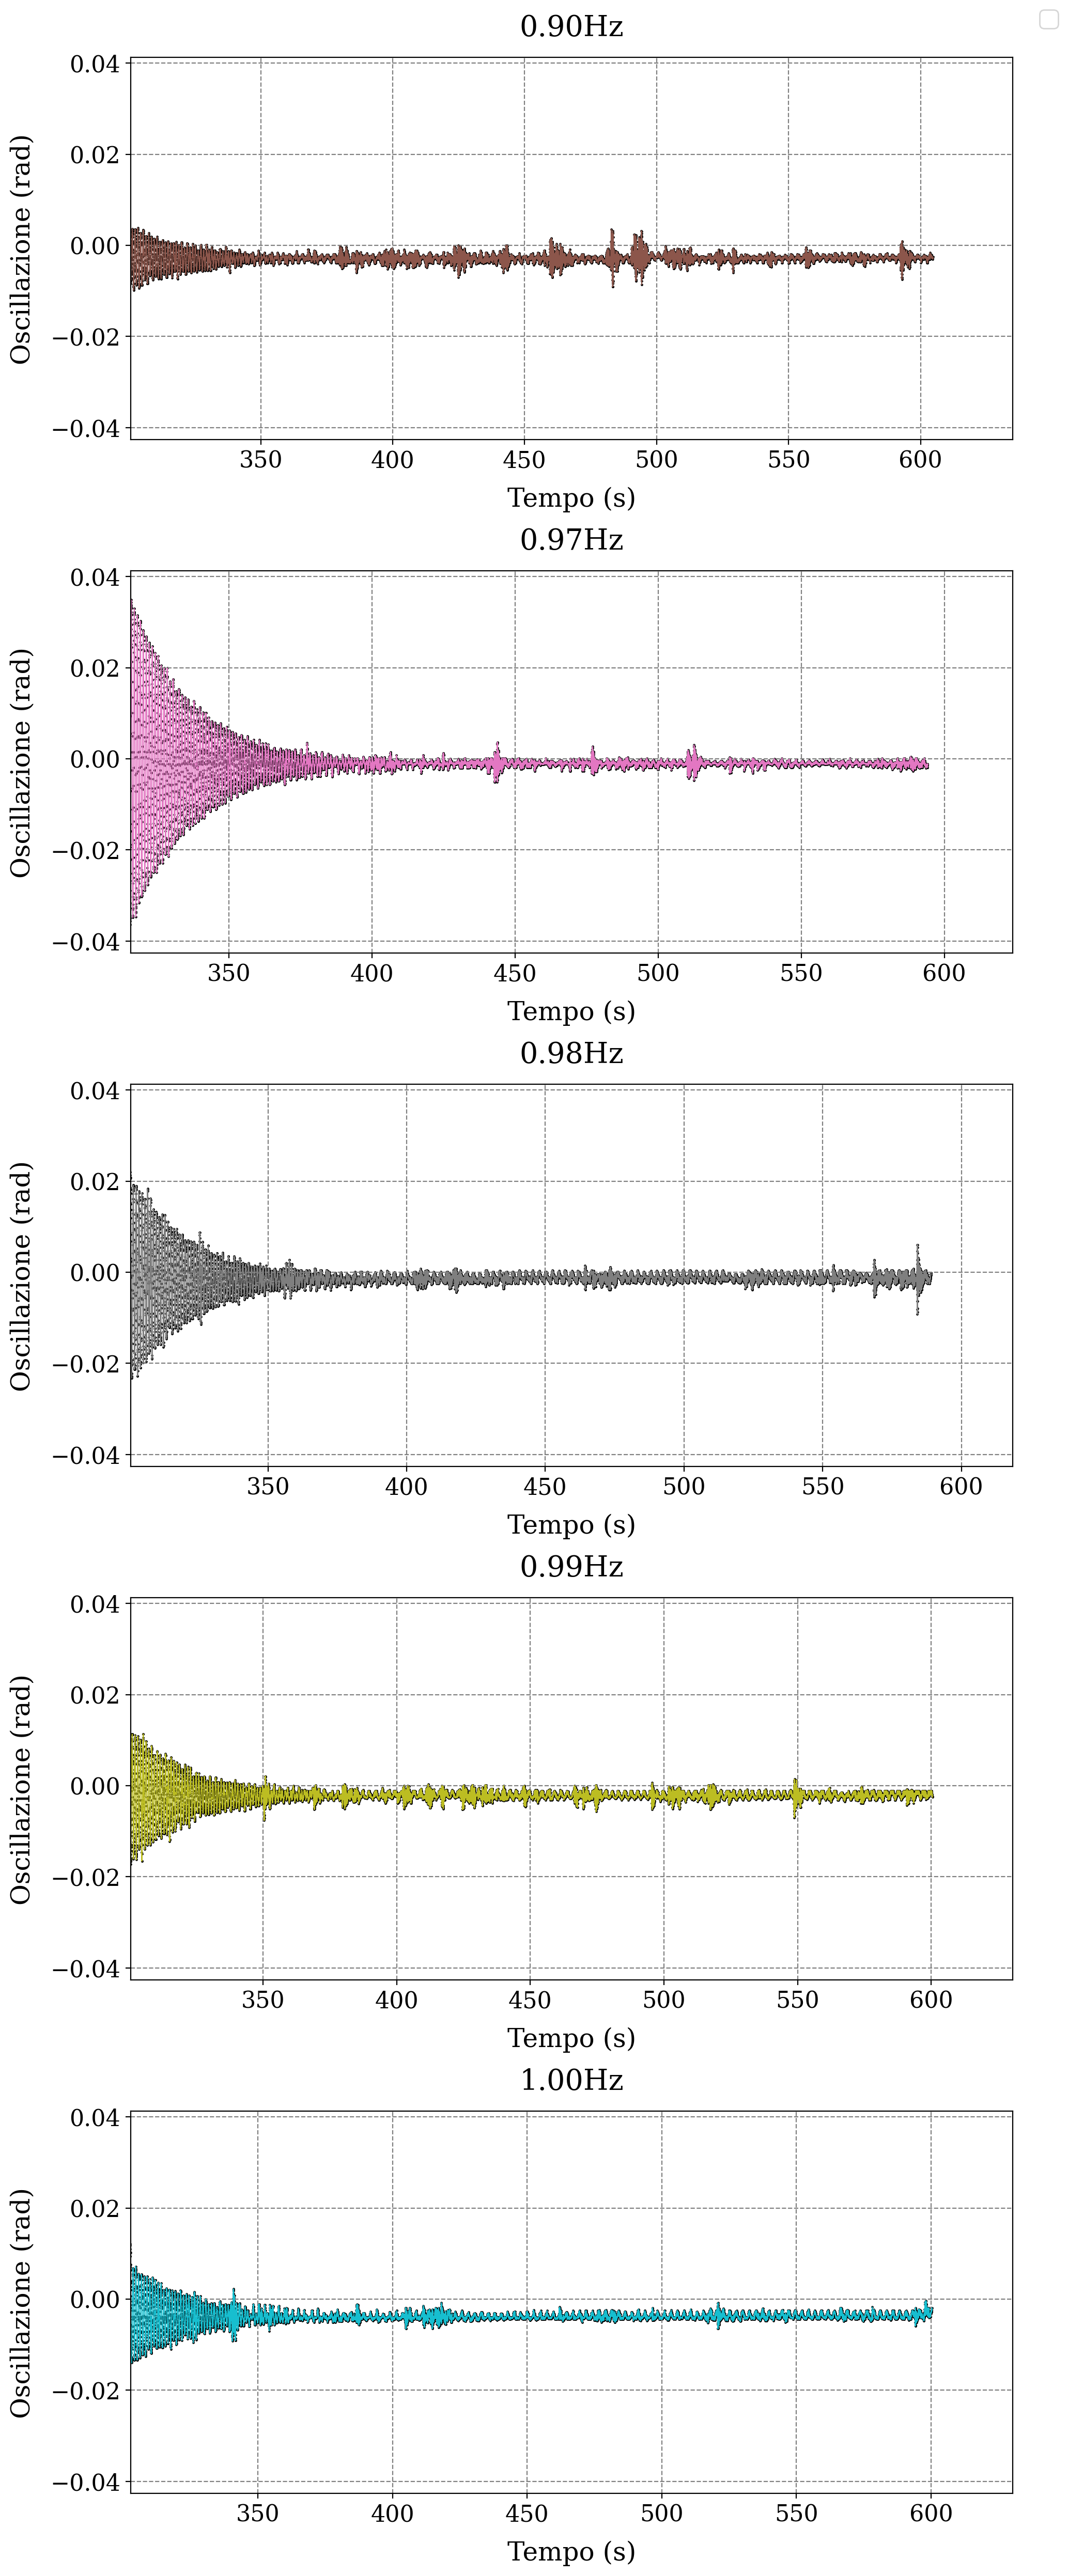

In [51]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, input_file in enumerate(input_files):

    ax = axes[i]

    titolo = nome(input_file)
    colore = next(color_cycle)

    x = dati[titolo]["tempo"]
    y = dati[titolo]["pendolo"] / (2*np.pi)

    ax.plot(x, y, color=colore, linewidth=0.7)
    ax.scatter(x, y, color="black", s=0.5)

    gf.parametri_grafico(ax, titolo, "Tempo (s)", "Oscillazione (rad)")

    # Calcolo indice di fine oscillazione forzante (inizio smorzamento)
    fine = np.argmin(abs(dati[titolo]["forzante"]))
    ax.set_xlim(x[fine],None)
gf.salva_grafico(fig, "./Images/ConfrontoSmorzati.pdf")

# Test

In [40]:
for chiave, serie in dati.items():
    tempi = serie['tempo']
    target = 300
    n = np.abs(np.array(tempi) - target).argmin()

    print(f"--- Serie {chiave} ---")
    print(f"Forzante: media = {np.mean(serie['forzante'][:n]):.3f}, deviazione = {np.std(serie['forzante'][:n], ddof=1):.3f}")
    print(f"Pendolo:  media = {np.mean(serie['pendolo'][:n]):.3f},  deviazione = {np.std(serie['pendolo'][:n], ddof=1):.3f}")
    print(f"Ampiezza: media = {np.mean(serie['ampiezza'][:n]):.3f}, deviazione = {np.std(serie['ampiezza'][:n], ddof=1):.3f}")
    print(f"Fase:     media = {np.mean(serie['fase'][:n]):.3f},     deviazione = {np.std(serie['fase'][:n], ddof=1):.3f}\n")


--- Serie 0.90Hz ---
Forzante: media = 0.149, deviazione = 23.809
Pendolo:  media = -0.009,  deviazione = 0.024
Ampiezza: media = 0.089, deviazione = 0.006
Fase:     media = 40.059,     deviazione = 173.513

--- Serie 0.97Hz ---
Forzante: media = 0.162, deviazione = 23.775
Pendolo:  media = -0.004,  deviazione = 0.159
Ampiezza: media = 0.460, deviazione = 0.004
Fase:     media = 44.750,     deviazione = 0.640

--- Serie 0.98Hz ---
Forzante: media = 0.133, deviazione = 23.776
Pendolo:  media = -0.006,  deviazione = 0.099
Ampiezza: media = 0.293, deviazione = 0.006
Fase:     media = 27.823,     deviazione = 0.483

--- Serie 0.99Hz ---
Forzante: media = 0.123, deviazione = 23.769
Pendolo:  media = -0.009,  deviazione = 0.067
Ampiezza: media = 0.201, deviazione = 0.004
Fase:     media = 19.695,     deviazione = 0.491

--- Serie 1.00Hz ---
Forzante: media = 0.158, deviazione = 23.771
Pendolo:  media = -0.013,  deviazione = 0.052
Ampiezza: media = 0.162, deviazione = 0.009
Fase:     media = 